In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
plt.style.use('ggplot')
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score, train_test_split

## 1. Charger les donnees

In [10]:
root = os.environ.get("HAR_DATA_DIR", "data/UCI HAR Dataset")  # override with your local dataset path

# Load Feature Names
features = pd.read_csv(
    os.path.join(root, "features.txt"),
    sep=r"\s+",          
    header=None,
    names=["idx", "feature"]
)
# Load Activity Labels
activity_labels = pd.read_csv(
    os.path.join(root, "activity_labels.txt"),
    sep=r"\s+",          # raw string
    header=None,
    names=["id", "activity"]
)
# Load Training Data
X_train = pd.read_csv(
    os.path.join(root, "train", "X_train.txt"),
    sep=r"\s+",           # raw string
    header=None
)
y_train = pd.read_csv(
    os.path.join(root, "train", "y_train.txt"),
    sep=r"\s+",
    header=None,
    names=["activity_id"]
)
subject_train = pd.read_csv(
    os.path.join(root, "train", "subject_train.txt"),
    sep=r"\s+",
    header=None,
    names=["subject"]
)
# Load Test Data
X_test = pd.read_csv(
    os.path.join(root, "test", "X_test.txt"),
    sep=r"\s+",
    header=None
)
y_test = pd.read_csv(
    os.path.join(root, "test", "y_test.txt"),
    sep=r"\s+",
    header=None,
    names=["activity_id"]
)
subject_test = pd.read_csv(
    os.path.join(root, "test", "subject_test.txt"),
    sep=r"\s+",
    header=None,
    names=["subject"]
)

In [11]:
# Assign Column Names ( so that they have meaning )
X_train.columns = features["feature"].values
X_test.columns = features["feature"].values

In [12]:
# Combine Train + Test for EDA
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)
subjects = pd.concat([subject_train, subject_test], axis=0).reset_index(drop=True)
df = pd.merge(y, activity_labels, left_on="activity_id", right_on="id", how="left")


#dataframe
df = pd.concat([subjects, y, X], axis=1)
print("Shape X_train:", X_train.shape, "X_test:", X_test.shape)
print("Shape combined df:", df.shape)

Shape X_train: (7352, 561) X_test: (2947, 561)
Shape combined df: (10299, 563)


## 2. Exploratory Data Analysis (EDA)
### a. Data Understanding
- DataFrame shape
- Columns' type
- Describe: informations and statustics about the numerical values of the data

In [13]:
#print 
# Dataset shape
print("Dataset shape:", df.shape)
print("================================================================================")
# Column names
print("Columns:", df.columns[:10], "...")  # show first 10 features
print("================================================================================")
#type
print("Columns' types:",df.dtypes)
print("================================================================================")
#describe
print("DataFrame description:", df.describe().T)
print()

Dataset shape: (10299, 563)
Columns: Index(['subject', 'activity_id', 'tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y',
       'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y',
       'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y'],
      dtype='object') ...
Columns' types: subject                                   int64
activity_id                               int64
tBodyAcc-mean()-X                       float64
tBodyAcc-mean()-Y                       float64
tBodyAcc-mean()-Z                       float64
                                         ...   
angle(tBodyGyroMean,gravityMean)        float64
angle(tBodyGyroJerkMean,gravityMean)    float64
angle(X,gravityMean)                    float64
angle(Y,gravityMean)                    float64
angle(Z,gravityMean)                    float64
Length: 563, dtype: object
DataFrame description:                                         count       mean       std  min  \
subject                               10299.0  16.146422 

### b. Feature Understanding (Univariate analysis)
- Plotting Feature Distribution
    - Histogram
    - KDE
    - Boxplot 

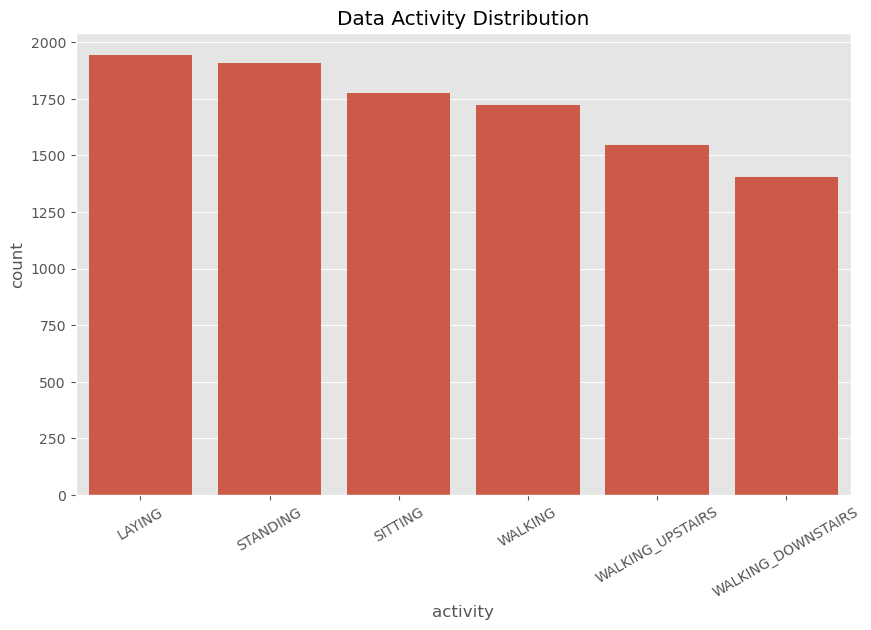

In [17]:
# Merge activity labels
df = df.merge(activity_labels, left_on='activity_id', right_on='id', how='left')

# Rename the column for convenience
df.rename(columns={'activity_name': 'activity'}, inplace=True)

# Now you can plot
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='activity', order=df['activity'].value_counts().index)
plt.xticks(rotation=30)
plt.title('Data Activity Distribution')
plt.show()


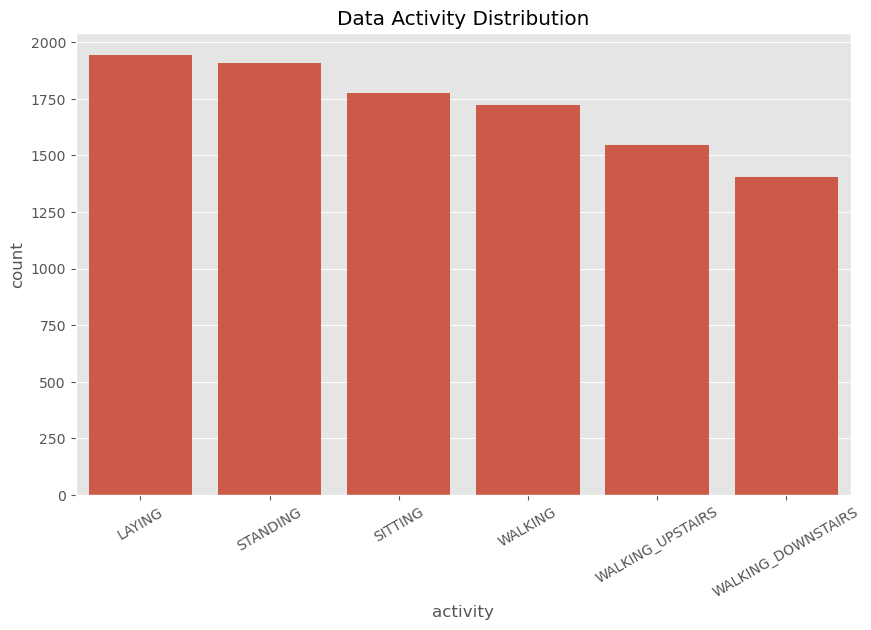

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='activity', order=df['activity'].value_counts().index)
plt.xticks(rotation=30)
plt.title('Data Activity Distribution')
plt.show()

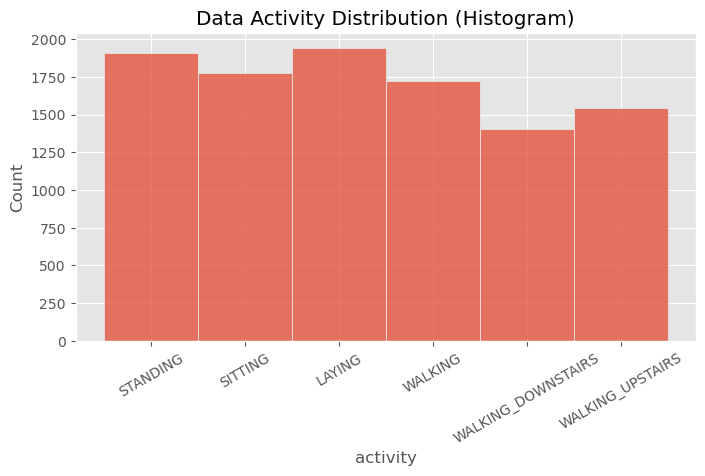

In [20]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='activity', bins=10)
plt.xticks(rotation=30)
plt.title('Data Activity Distribution (Histogram)')
plt.show()

Text(0, 0.5, 'Count')

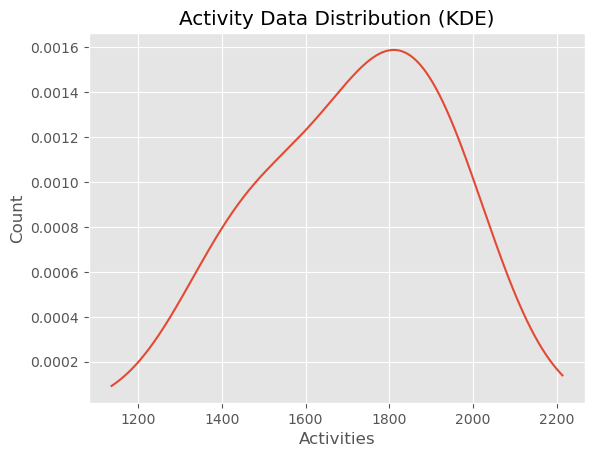

In [21]:
ax=df['activity'].value_counts().plot(kind='kde',title="Activity Data Distribution (KDE)")
ax.set_xlabel('Activities')
ax.set_ylabel('Count')

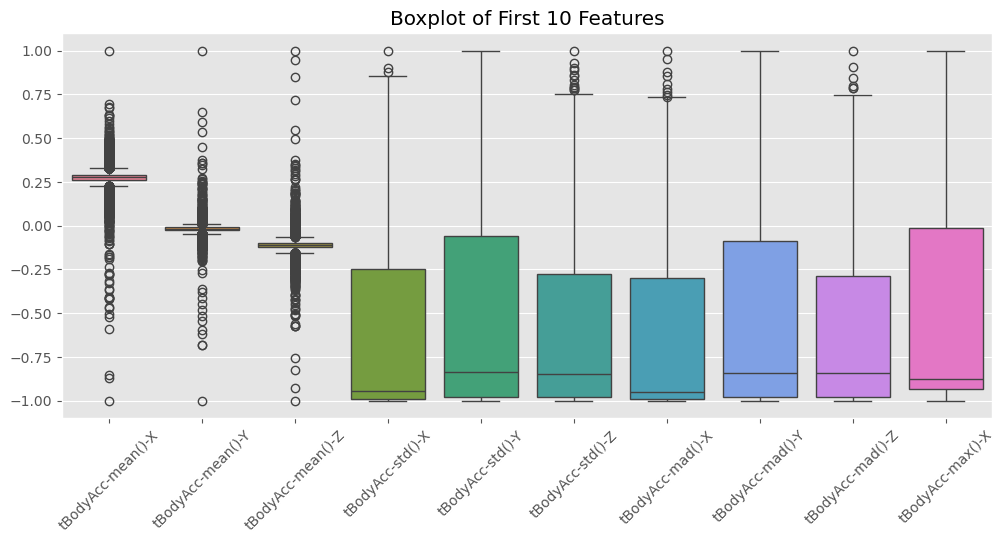

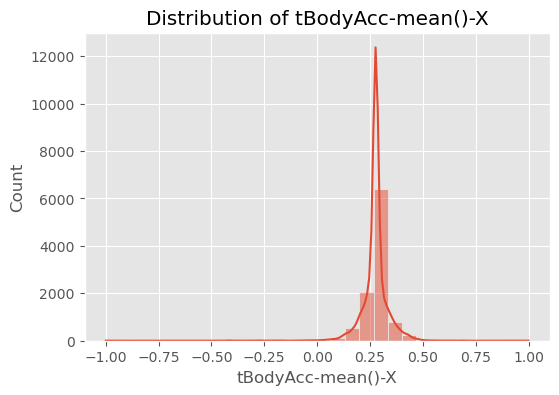

In [22]:
# Boxplot of first 10 features
plt.figure(figsize=(12,5))
sns.boxplot(data=df.iloc[:,2:12])
plt.xticks(rotation=45)
plt.title("Boxplot of First 10 Features")
plt.show()

# Histogram of a feature
plt.figure(figsize=(6,4))
sns.histplot(df['tBodyAcc-mean()-X'], bins=30, kde=True)
plt.title("Distribution of tBodyAcc-mean()-X")
plt.show()


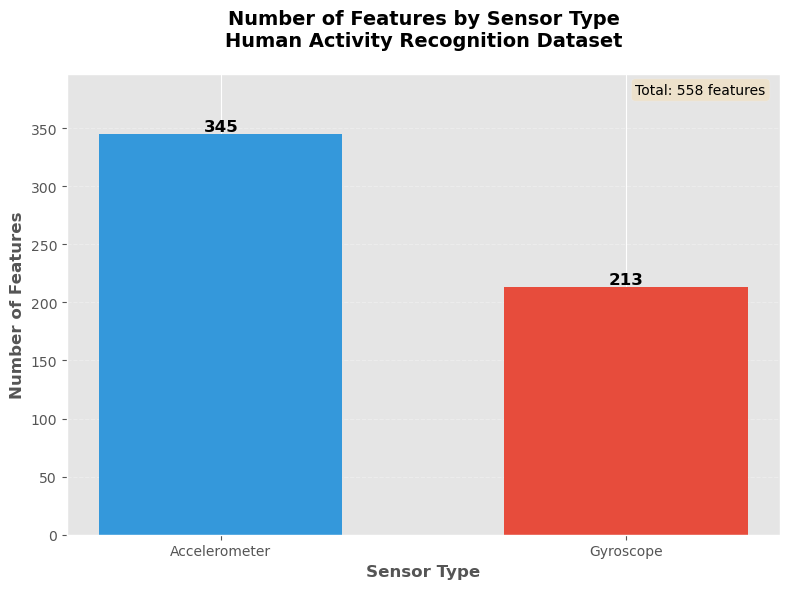

Accelerometer features: 345
Gyroscope features: 213
Total sensor features: 558


In [23]:
# Count features from each sensor type
# Accelerometer features typically contain 'Acc' in their name
# Gyroscope features typically contain 'Gyro' in their name

acc_features = [col for col in df.columns if 'Acc' in col]
gyro_features = [col for col in df.columns if 'Gyro' in col]

# Create counts
sensor_counts = {
    'Accelerometer': len(acc_features),
    'Gyroscope': len(gyro_features)
}

# Create the bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(sensor_counts.keys(), sensor_counts.values(), 
               color=['#3498db', '#e74c3c'], width=0.6)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize the plot
plt.title('Number of Features by Sensor Type\nHuman Activity Recognition Dataset', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of Features', fontsize=12, fontweight='bold')
plt.xlabel('Sensor Type', fontsize=12, fontweight='bold')
plt.ylim(0, max(sensor_counts.values()) * 1.15)  # Add space for labels
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add total features annotation
total = sum(sensor_counts.values())
plt.text(0.98, 0.98, f'Total: {total} features', 
         transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary
print(f"Accelerometer features: {len(acc_features)}")
print(f"Gyroscope features: {len(gyro_features)}")
print(f"Total sensor features: {total}")

a: Feature/Sensor Importance from Domain Knowledge
Stationary activities (lying, standing, and sitting) are those where there is no motion of an object. Moving activities (Walking, Walking Upstairs, and Walking Downstairs) are those where there is the motion of an object. That means, in motionless activities, accelerometer information will not be very significant whereas in motion activities accelerometer information will be useful. Fig. 5 shows the number of features in the dataset that come from the accelerometer and gyroscope sensor of the smartphone. As we see, most of the features are constructed from accelerometer sensors so moving activities will easily be distinguished.

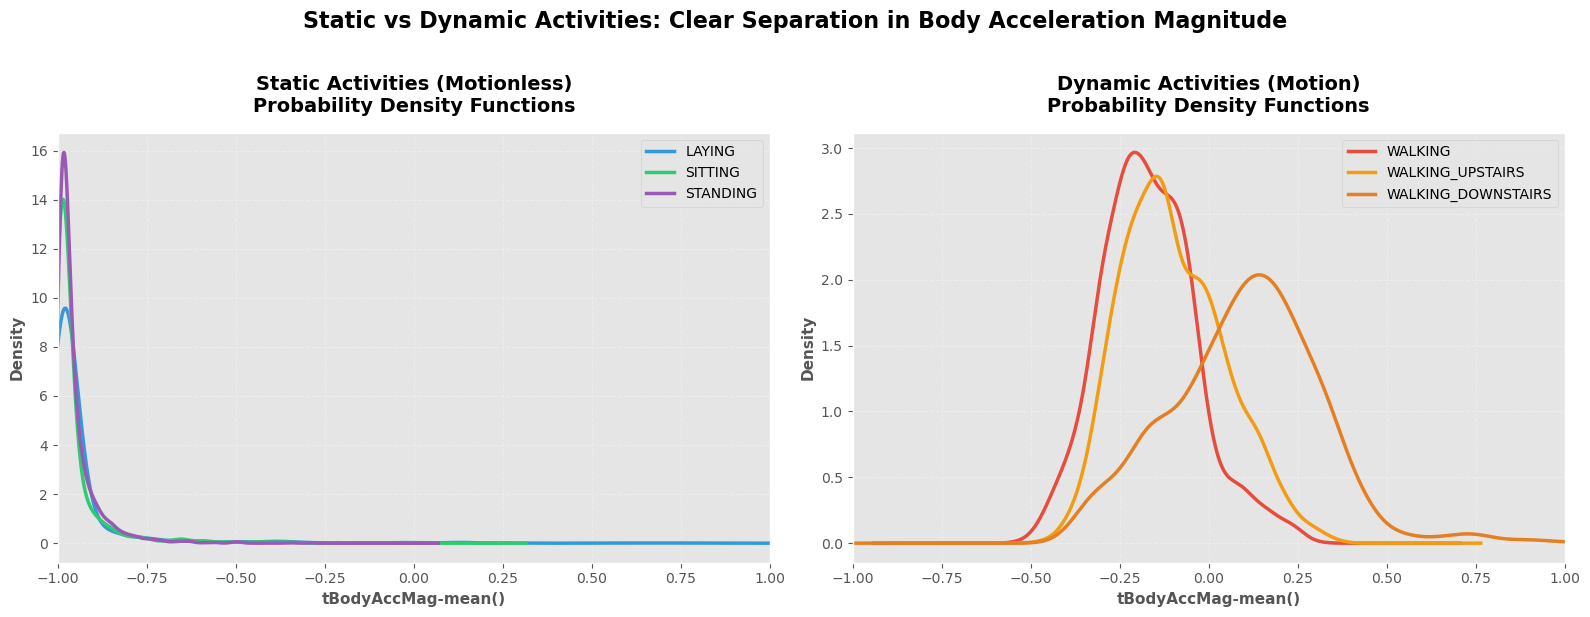

STATISTICAL COMPARISON: Static vs Dynamic Activities

Feature: tBodyAccMag-mean()

STATIC ACTIVITIES (Motionless):
  LAYING               - Mean: -0.9411, Std: 0.1455
  SITTING              - Mean: -0.9546, Std: 0.0871
  STANDING             - Mean: -0.9542, Std: 0.0625

DYNAMIC ACTIVITIES (Motion):
  WALKING              - Mean: -0.1679, Std: 0.1337
  WALKING_UPSTAIRS     - Mean: -0.1002, Std: 0.1442
  WALKING_DOWNSTAIRS   - Mean: 0.1012, Std: 0.2103



In [24]:
# Define the feature to analyze
feature = 'tBodyAccMag-mean()'

# Define activity groups
static_activities = ['LAYING', 'SITTING', 'STANDING']
dynamic_activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Color palettes
static_colors = ['#3498db', '#2ecc71', '#9b59b6']
dynamic_colors = ['#e74c3c', '#f39c12', '#e67e22']

# Plot 1: Static Activities
for activity, color in zip(static_activities, static_colors):
    data = df[df['activity'] == activity][feature]
    data.plot(kind='density', ax=ax1, label=activity, color=color, linewidth=2.5)

ax1.set_title('Static Activities (Motionless)\nProbability Density Functions', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel(f'{feature}', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df[feature].min(), df[feature].max())

# Plot 2: Dynamic Activities
for activity, color in zip(dynamic_activities, dynamic_colors):
    data = df[df['activity'] == activity][feature]
    data.plot(kind='density', ax=ax2, label=activity, color=color, linewidth=2.5)

ax2.set_title('Dynamic Activities (Motion)\nProbability Density Functions', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel(f'{feature}', fontsize=11, fontweight='bold')
ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(df[feature].min(), df[feature].max())

# Add main title
fig.suptitle('Static vs Dynamic Activities: Clear Separation in Body Acceleration Magnitude', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Print statistics for comparison
print("="*60)
print("STATISTICAL COMPARISON: Static vs Dynamic Activities")
print("="*60)
print(f"\nFeature: {feature}\n")

print("STATIC ACTIVITIES (Motionless):")
for activity in static_activities:
    data = df[df['activity'] == activity][feature]
    print(f"  {activity:20s} - Mean: {data.mean():.4f}, Std: {data.std():.4f}")

print("\nDYNAMIC ACTIVITIES (Motion):")
for activity in dynamic_activities:
    data = df[df['activity'] == activity][feature]
    print(f"  {activity:20s} - Mean: {data.mean():.4f}, Std: {data.std():.4f}")

print("\n" + "="*60)

C:\Users\User\AppData\Local\Temp\ipykernel_7616\1823957039.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df[df['activity'] == activity][feature] for activity in activity_order],


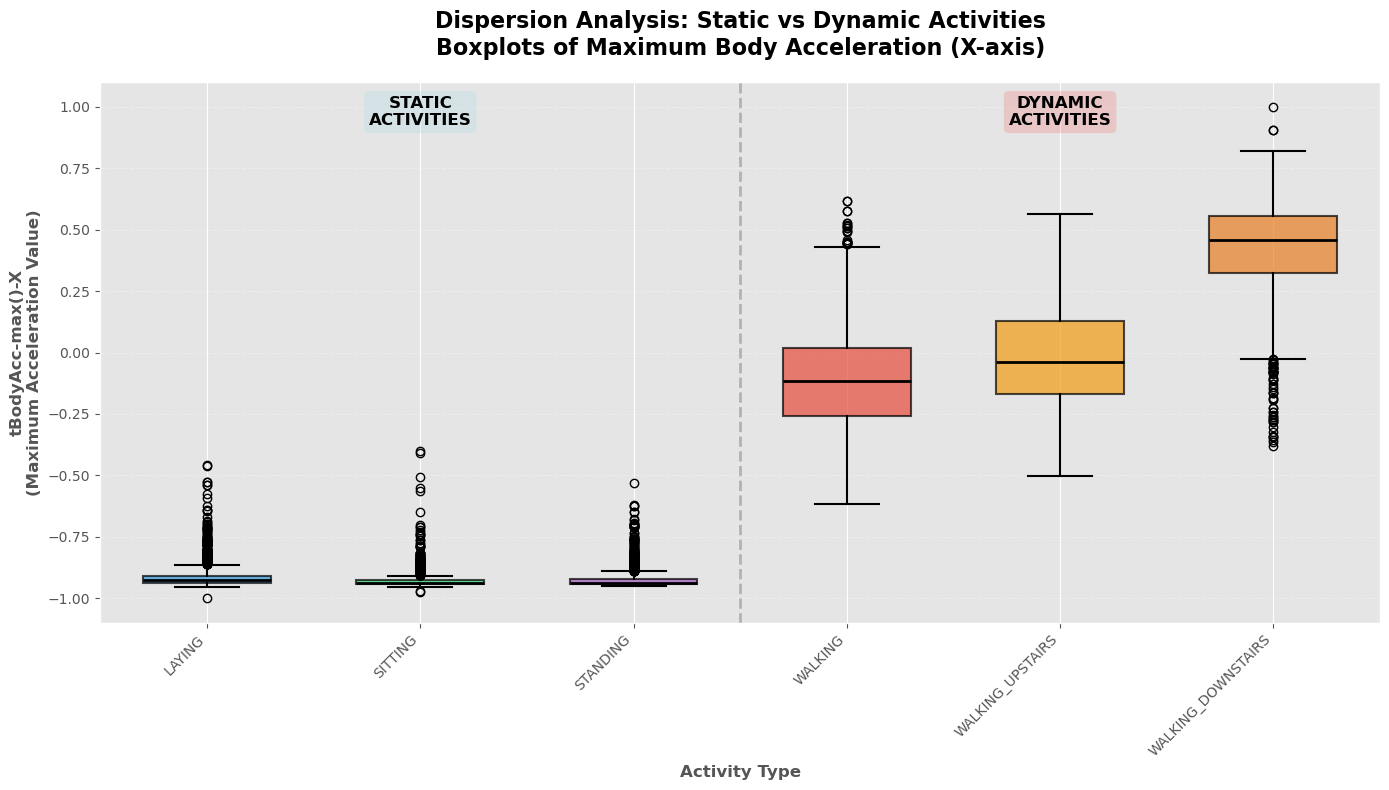

DISPERSION ANALYSIS: Static vs Dynamic Activities

Feature: tBodyAcc-max()-X

STATIC ACTIVITIES (Low Dispersion):
Activity                  Mean       Std        IQR       
----------------------------------------------------------------------
LAYING                    -0.9116    0.0480     0.0295    
SITTING                   -0.9267    0.0366     0.0134    
STANDING                  -0.9213    0.0404     0.0204    

DYNAMIC ACTIVITIES (High Dispersion):
Activity                  Mean       Std        IQR       
----------------------------------------------------------------------
WALKING                   -0.1135    0.2155     0.2760    
WALKING_UPSTAIRS          -0.0150    0.1937     0.2958    
WALKING_DOWNSTAIRS        0.4172     0.2029     0.2333    

INTERPRETATION:
- Static activities show NARROW boxes (low dispersion/variability)
- Dynamic activities show WIDER boxes (high dispersion/variability)
- IQR (Interquartile Range) quantifies the box height/spread


In [25]:
# Define the feature to analyze
feature = 'tBodyAcc-max()-X'

# Define activity order (static then dynamic)
activity_order = ['LAYING', 'SITTING', 'STANDING', 
                  'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

# Define colors for each activity type
colors = ['#3498db', '#2ecc71', '#9b59b6',  # Static activities
          '#e74c3c', '#f39c12', '#e67e22']  # Dynamic activities

# Create the figure
fig, ax = plt.subplots(figsize=(14, 8))

# Create boxplot
bp = ax.boxplot([df[df['activity'] == activity][feature] for activity in activity_order],
                 labels=activity_order,
                 patch_artist=True,
                 widths=0.6,
                 showfliers=True,
                 medianprops=dict(color='black', linewidth=2),
                 boxprops=dict(linewidth=1.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add vertical separator between static and dynamic activities
ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)

# Add labels for activity types
ax.text(2, ax.get_ylim()[1] * 0.95, 'STATIC\nACTIVITIES', 
        ha='center', va='top', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(5, ax.get_ylim()[1] * 0.95, 'DYNAMIC\nACTIVITIES', 
        ha='center', va='top', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# Customize the plot
ax.set_title('Dispersion Analysis: Static vs Dynamic Activities\nBoxplots of Maximum Body Acceleration (X-axis)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel(f'{feature}\n(Maximum Acceleration Value)', 
              fontsize=12, fontweight='bold')
ax.set_xlabel('Activity Type', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print statistical analysis
print("="*70)
print("DISPERSION ANALYSIS: Static vs Dynamic Activities")
print("="*70)
print(f"\nFeature: {feature}\n")

print("STATIC ACTIVITIES (Low Dispersion):")
print(f"{'Activity':<25} {'Mean':<10} {'Std':<10} {'IQR':<10}")
print("-"*70)
for activity in activity_order[:3]:
    data = df[df['activity'] == activity][feature]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    print(f"{activity:<25} {data.mean():<10.4f} {data.std():<10.4f} {iqr:<10.4f}")

print("\nDYNAMIC ACTIVITIES (High Dispersion):")
print(f"{'Activity':<25} {'Mean':<10} {'Std':<10} {'IQR':<10}")
print("-"*70)
for activity in activity_order[3:]:
    data = df[df['activity'] == activity][feature]
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    print(f"{activity:<25} {data.mean():<10.4f} {data.std():<10.4f} {iqr:<10.4f}")

print("\n" + "="*70)
print("INTERPRETATION:")
print("- Static activities show NARROW boxes (low dispersion/variability)")
print("- Dynamic activities show WIDER boxes (high dispersion/variability)")
print("- IQR (Interquartile Range) quantifies the box height/spread")
print("="*70)

Applying t-SNE dimensionality reduction...
This may take a minute for large datasets...


C:\Users\User\anaconda3\envs\workshop\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed!


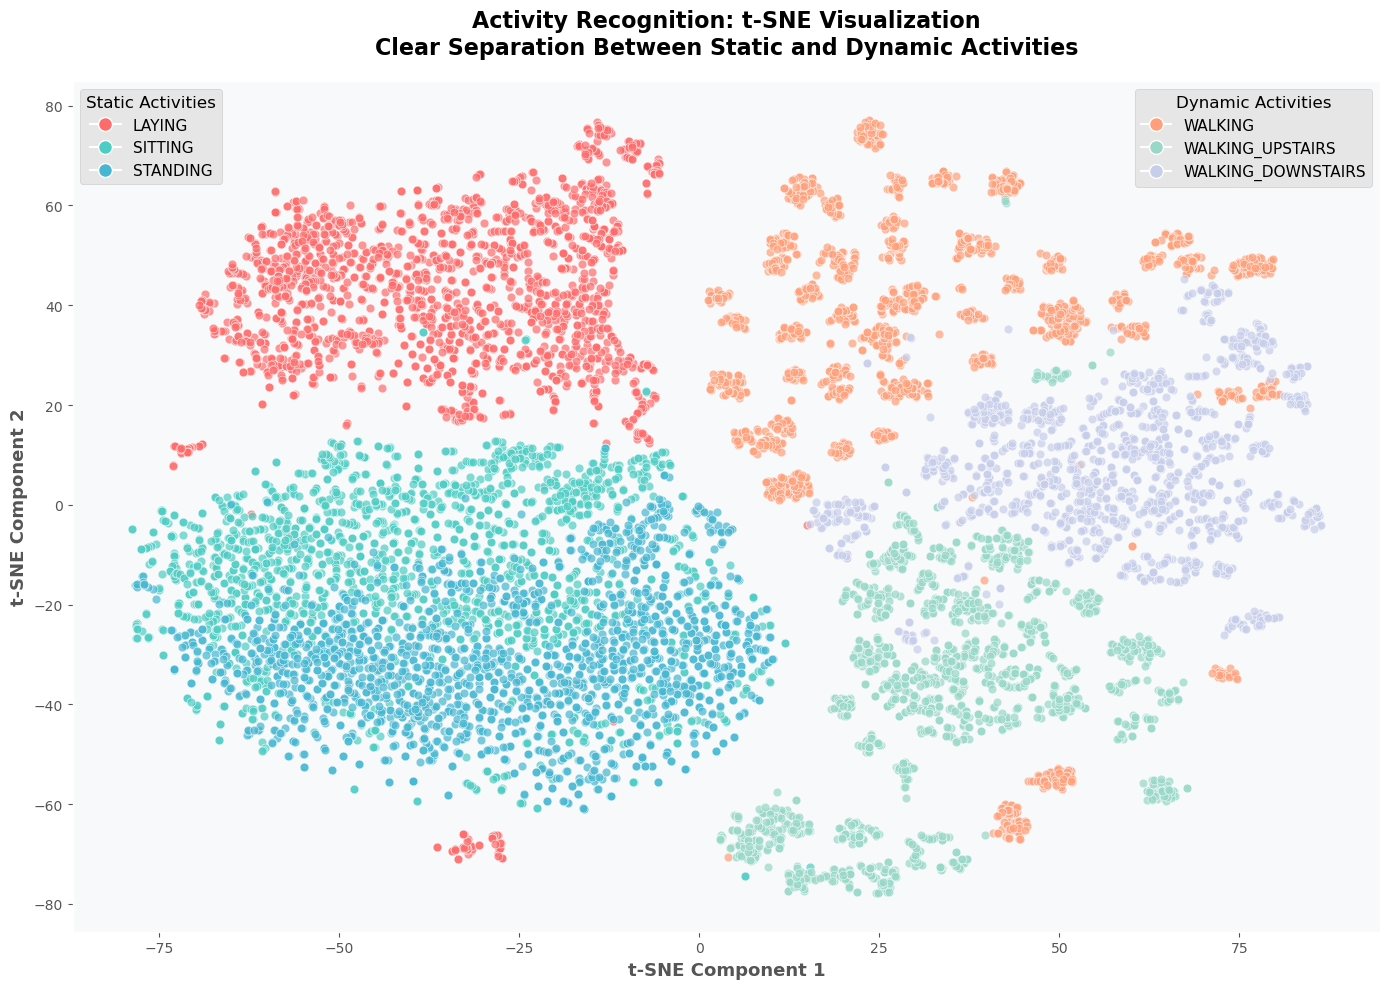


CLUSTER ANALYSIS: Activity Distribution

Total samples: 10,299
Original dimensions: 564
Reduced dimensions: 2 (t-SNE)

ACTIVITY DISTRIBUTION:
----------------------------------------------------------------------
Activity                  Count      Percentage
----------------------------------------------------------------------
LAYING                    1,944       18.88%
SITTING                   1,777       17.25%
STANDING                  1,906       18.51%
WALKING                   1,722       16.72%
WALKING_UPSTAIRS          1,544       14.99%
WALKING_DOWNSTAIRS        1,406       13.65%

WHY t-SNE WORKS BETTER:
----------------------------------------------------------------------
✓ Preserves local neighborhood structure
✓ Creates well-separated, tight clusters for different classes
✓ Excellent for visualizing high-dimensional data
✓ Reveals natural groupings (static vs dynamic activities)
✓ Non-linear method that captures complex patterns


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Prepare the data
y = df['activity']
X = df.select_dtypes(include=[np.number])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply t-SNE for dimensionality reduction
# t-SNE is excellent for visualization as it preserves local structure
print("Applying t-SNE dimensionality reduction...")
print("This may take a minute for large datasets...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE completed!")

# Define colors for activities - using distinct, visually appealing colors
activity_colors = {
    'LAYING': '#FF6B6B',           # Coral red
    'SITTING': '#4ECDC4',          # Turquoise
    'STANDING': '#45B7D1',         # Sky blue
    'WALKING': '#FFA07A',          # Light salmon
    'WALKING_UPSTAIRS': '#98D8C8', # Mint green
    'WALKING_DOWNSTAIRS': '#C7CEEA' # Lavender
}

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Plot each activity with distinct styling
for activity in activity_colors.keys():
    mask = y == activity
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=activity_colors[activity],
               label=activity,
               alpha=0.7,
               s=40,
               edgecolors='white',
               linewidth=0.5)

# Customize the plot
ax.set_title('Activity Recognition: t-SNE Visualization\nClear Separation Between Static and Dynamic Activities', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('t-SNE Component 1', fontsize=13, fontweight='bold')
ax.set_ylabel('t-SNE Component 2', fontsize=13, fontweight='bold')

# Create a better legend with grouping
static_legend = ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                                              markerfacecolor=activity_colors[act], 
                                              markersize=10, label=act)
                                   for act in ['LAYING', 'SITTING', 'STANDING']],
                         title='Static Activities', 
                         loc='upper left',
                         fontsize=11,
                         title_fontsize=12,
                         framealpha=0.95)

# Add second legend for dynamic activities
ax.add_artist(static_legend)
ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=activity_colors[act], 
                              markersize=10, label=act)
                  for act in ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']],
         title='Dynamic Activities',
         loc='upper right',
         fontsize=11,
         title_fontsize=12,
         framealpha=0.95)

ax.grid(True, alpha=0.2, linestyle='--')
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

# Print cluster statistics
print("\n" + "="*70)
print("CLUSTER ANALYSIS: Activity Distribution")
print("="*70)
print(f"\nTotal samples: {X.shape[0]:,}")
print(f"Original dimensions: {X.shape[1]}")
print(f"Reduced dimensions: 2 (t-SNE)\n")

print("ACTIVITY DISTRIBUTION:")
print("-"*70)
print(f"{'Activity':<25} {'Count':<10} {'Percentage':<10}")
print("-"*70)

for activity in ['LAYING', 'SITTING', 'STANDING', 
                 'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']:
    count = (y == activity).sum()
    percentage = (count / len(y)) * 100
    print(f"{activity:<25} {count:<10,} {percentage:>6.2f}%")

print("\n" + "="*70)
print("WHY t-SNE WORKS BETTER:")
print("-"*70)
print("✓ Preserves local neighborhood structure")
print("✓ Creates well-separated, tight clusters for different classes")
print("✓ Excellent for visualizing high-dimensional data")
print("✓ Reveals natural groupings (static vs dynamic activities)")
print("✓ Non-linear method that captures complex patterns")
print("="*70)

### Feature Relationships
goal: compare the different features of dataset
- Scatterplot
- Heatmap Correlation
- Pairplot
- Groupby comparisons
#### scatterplot:
study the relationship between "tBodyAcc-mean()-X" and "tBodyAcc-mean()-Z",

# kmeans

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [29]:
# Drop non-numeric columns
X_features = df.drop(columns=['subject', 'activity', 'activity_id'])

# Standardize features (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)


In [30]:
# Choose number of clusters
k = df['activity'].nunique()  # you can use number of activity types

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


In [31]:
# Compare clusters with actual activities
pd.crosstab(df['cluster'], df['activity'])


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
cluster,,,,,,
0,1360,1098,915,0,0,0
1,0,0,0,726,869,141
2,0,0,0,99,227,10
3,12,3,0,810,293,1031
4,0,0,0,87,17,362
5,572,676,991,0,0,0


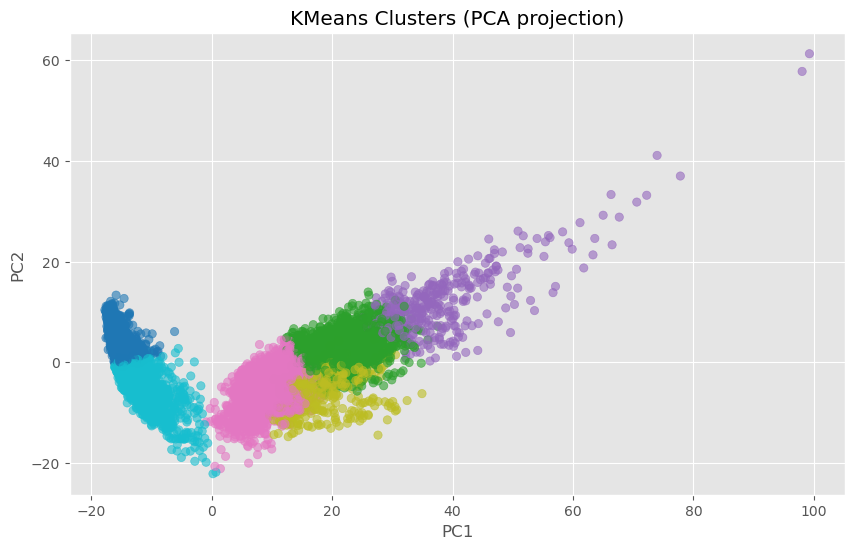

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='tab10', alpha=0.6)
plt.title('KMeans Clusters (PCA projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


activity       LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
agglo_cluster                                                           
0                   0        0         0     1339                 539   
1                   0        0         0      355                 744   
2                1635       16         1        0                   0   
3                 307      661       847        0                   0   
4                   0        0         0       28                 123   
5                   2     1100      1058        0                   0   

activity       WALKING_UPSTAIRS  
agglo_cluster                    
0                          1335  
1                           209  
2                             0  
3                             0  
4                             0  
5                             0  


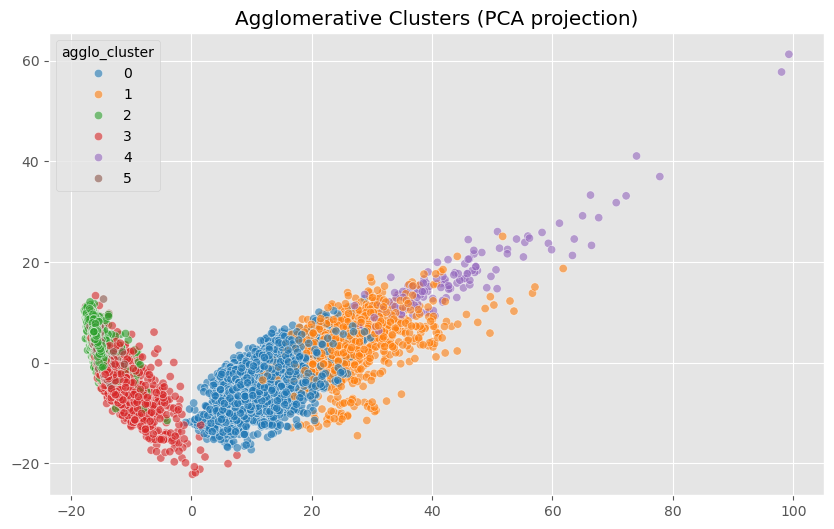

In [33]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Use the same X_scaled from before
# Number of clusters = number of activity types
n_clusters = df['activity'].nunique()

agglo = AgglomerativeClustering(n_clusters=n_clusters)
df['agglo_cluster'] = agglo.fit_predict(X_scaled)

# Compare clusters with actual activity
print(pd.crosstab(df['agglo_cluster'], df['activity']))

# Optional: visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['agglo_cluster'], palette='tab10', alpha=0.6)
plt.title('Agglomerative Clusters (PCA projection)')
plt.show()


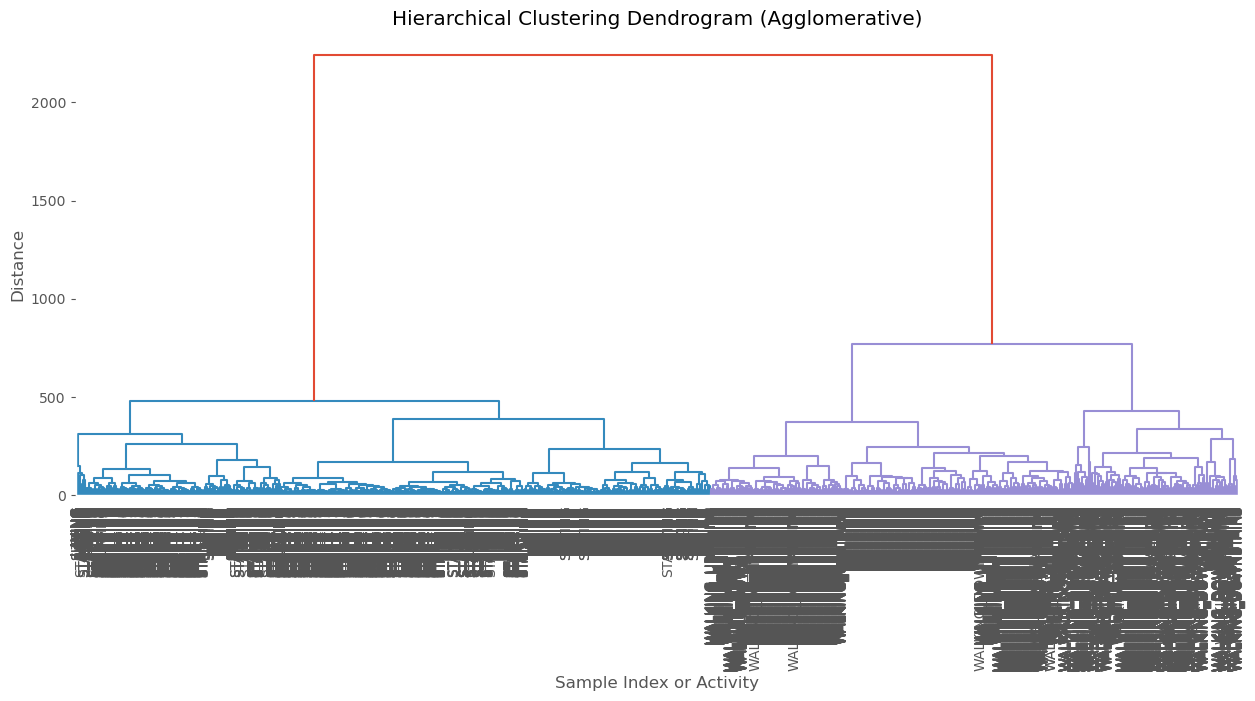

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Compute the linkage matrix (using Ward method, good for Euclidean distances)
Z = linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 6))
dendrogram(Z, 
           truncate_mode='level',  # show only top levels
           p=30,                   # number of levels to show
           labels=df['activity'].values,  # optional: show activity names
           leaf_rotation=90, 
           leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Agglomerative)')
plt.xlabel('Sample Index or Activity')
plt.ylabel('Distance')
plt.show()


dbscan_cluster
-1    10299
Name: count, dtype: int64
activity        LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
dbscan_cluster                                                           
-1                1944     1777      1906     1722                1406   

activity        WALKING_UPSTAIRS  
dbscan_cluster                    
-1                          1544  


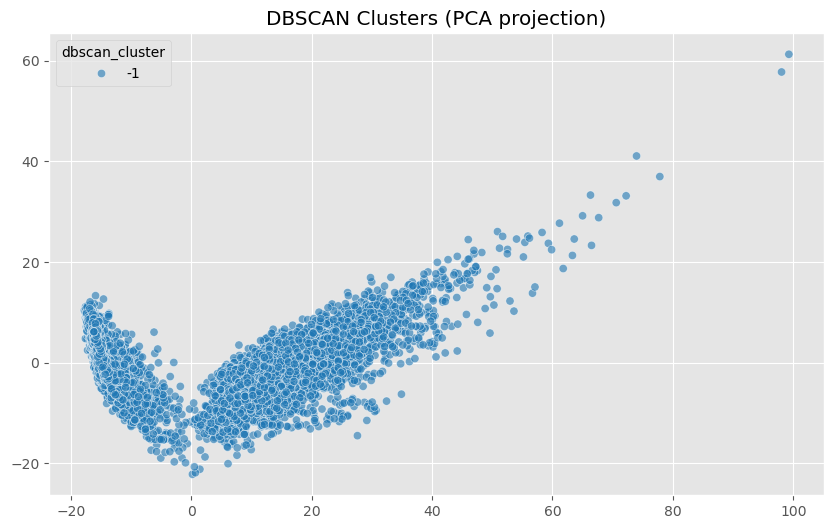

In [35]:
from sklearn.cluster import DBSCAN

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5) 
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Inspect results
print(df['dbscan_cluster'].value_counts())  # -1 are outliers
print(pd.crosstab(df['dbscan_cluster'], df['activity']))

# Optional: visualize
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['dbscan_cluster'], palette='tab10', alpha=0.6)
plt.title('DBSCAN Clusters (PCA projection)')
plt.show()


In [36]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)


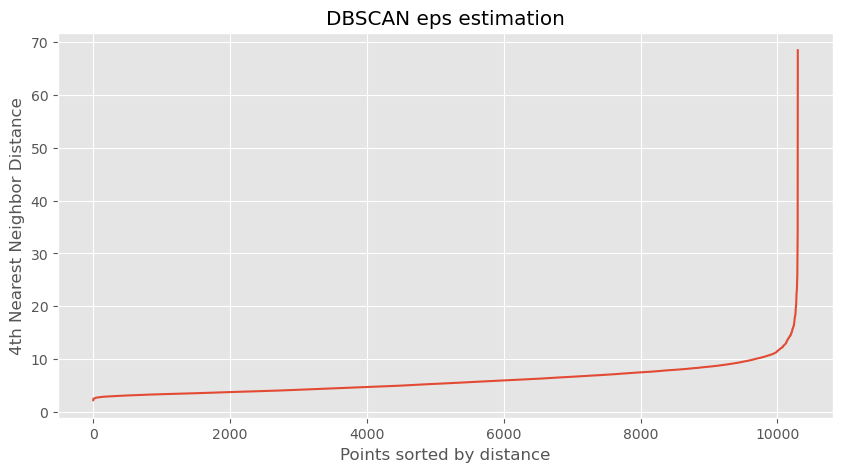

In [37]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Sort distances to find "elbow"
distances = np.sort(distances[:,4])  # 4th neighbor distance
plt.figure(figsize=(10,5))
plt.plot(distances)
plt.ylabel('4th Nearest Neighbor Distance')
plt.xlabel('Points sorted by distance')
plt.title('DBSCAN eps estimation')
plt.show()


In [40]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=5, min_samples=5)  # adjust eps based on k-distance plot
df['dbscan_cluster'] = dbscan.fit_predict(X_pca)

print(df['dbscan_cluster'].value_counts())


dbscan_cluster
 0    10293
-1        6
Name: count, dtype: int64


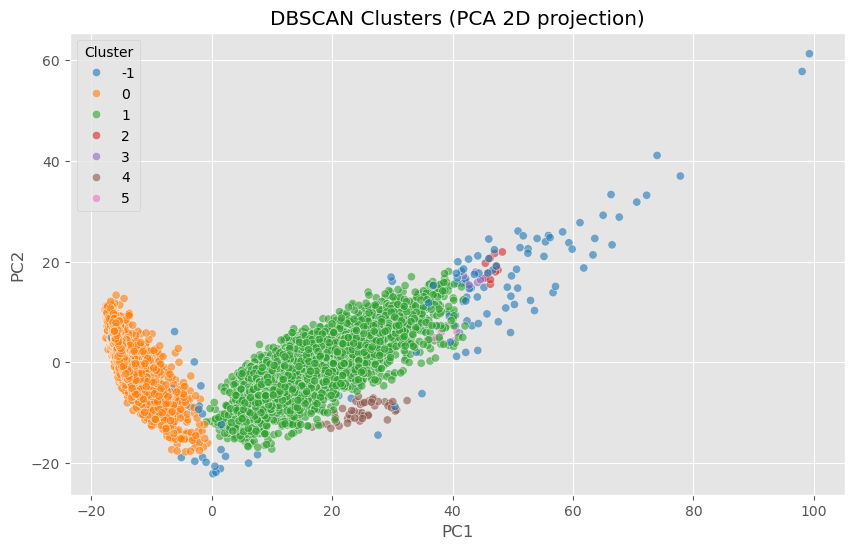

In [47]:
# 1️⃣ Reduce dimensionality for DBSCAN
pca = PCA(n_components=3)  # 2D for plotting
X_pca = pca.fit_transform(X_scaled)

# 2️⃣ Apply DBSCAN (tune eps as needed)
dbscan = DBSCAN(eps=3, min_samples=5)  # adjust eps after trying
clusters = dbscan.fit_predict(X_pca)
df['dbscan_cluster'] = clusters

# 3️⃣ Plot clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['dbscan_cluster'], 
                palette='tab10', alpha=0.6)
plt.title('DBSCAN Clusters (PCA 2D projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

In [49]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

def evaluate(clusters, X, y_true):
    print("Silhouette Score:", silhouette_score(X, clusters))
    print("Davies-Bouldin Score:", davies_bouldin_score(X, clusters))
    print("Adjusted Rand Index:", adjusted_rand_score(y_true, clusters))
    print("Adjusted Mutual Information:", adjusted_mutual_info_score(y_true, clusters))

# Example for K-Means
evaluate(df['cluster'], X_scaled, y)


Silhouette Score: 0.11688980679131775
Davies-Bouldin Score: 2.5269266958046734
Adjusted Rand Index: 0.2852031231245627
Adjusted Mutual Information: 0.4611168057360744


In [50]:
# Example for K-Means
evaluate(df['agglo_cluster'], X_scaled, y)

Silhouette Score: 0.10571938252617667
Davies-Bouldin Score: 2.471684760952137
Adjusted Rand Index: 0.4255689755401141
Adjusted Mutual Information: 0.5865785060685305


In [51]:
# Example for K-Means
evaluate(df['dbscan_cluster'], X_scaled, y)

Silhouette Score: 0.3587583489780854
Davies-Bouldin Score: 2.7247785105677416
Adjusted Rand Index: 0.32981609729555655
Adjusted Mutual Information: 0.5398615011268648
